# Wikipedia Text Pair Benchmark Dataset

This notebook demonstrates the **Wikipedia Text Pair Benchmark** — a synthetic dataset of 900 labeled text pairs built from Wikipedia articles via the Wikipedia API.

**Three classes (300 each):**
- `near_duplicate` — text_b is a splice-edited version of text_a (5-gram Jaccard 0.42–0.70)
- `hard_negative` — two articles from the *same* Wikipedia category (thematically similar, not textually)
- `random` — articles from *different* categories (easy negatives, Jaccard ≈ 0)

**Key insight:** 5-gram Jaccard cleanly separates near-duplicates from both negative classes, making it a strong baseline feature.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru is NOT pre-installed on Colab
_pip('loguru==0.7.3')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import sys
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

from loguru import logger
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-f2202a-edit-clustering-score-spatial-edit-patte/main/round-1/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
logger.info(f"Loaded dataset: {data['metadata']['description']}")

11:53:01|INFO   |Loaded dataset: 900 labeled text pairs: near_duplicate (splice edit), hard_negative (same category), random (different categories)


## Config

Tunable parameters for the demo. Set to minimum values for a quick run; scale up for fuller analysis.

In [5]:
# Minimum: works on any number of examples
N_GRAM = 5           # n-gram size for Jaccard similarity (original: 5)
N_EXAMPLES = None    # None = use all loaded examples; set to int to limit
RANDOM_SEED = 42

## Parse Dataset

The dataset stores each example with an `input` field containing a JSON string of `text_a` and `text_b`, and an `output` field with the class label. We unpack these for analysis.

In [6]:
examples = data["datasets"][0]["examples"]
if N_EXAMPLES is not None:
    examples = examples[:N_EXAMPLES]

rows = []
for ex in examples:
    inp = json.loads(ex["input"])
    rows.append({
        "text_a": inp["text_a"],
        "text_b": inp["text_b"],
        "label": ex["output"],
        "pair_id": ex["metadata_pair_id"],
        "fold": ex["metadata_fold"],
        "jaccard_5gram": ex["metadata_jaccard_5gram"],
        "word_count_a": ex["metadata_word_count_a"],
        "word_count_b": ex["metadata_word_count_b"],
        "category": ex["metadata_category"],
    })

df = pd.DataFrame(rows)
logger.info(f"Parsed {len(df)} pairs. Label distribution: {df['label'].value_counts().to_dict()}")
print(df[["pair_id", "label", "category", "jaccard_5gram", "word_count_a", "word_count_b"]].to_string(index=False))

11:53:02|INFO   |Parsed 9 pairs. Label distribution: {'near_duplicate': 3, 'hard_negative': 3, 'random': 3}


pair_id          label     category  jaccard_5gram  word_count_a  word_count_b
 nd_296 near_duplicate         arts         0.5474           800           800
 nd_084 near_duplicate architecture         0.6297           800           800
 nd_287 near_duplicate architecture         0.5671           800           800
 hn_101  hard_negative       nature         0.0000           800           800
 hn_141  hard_negative   technology         0.0000           227           800
 hn_018  hard_negative      history         0.0000           800           800
rnd_082         random        mixed         0.0000           800           800
rnd_295         random        mixed         0.0000           800           800
rnd_252         random        mixed         0.0000           400           433


## Feature Engineering

We compute two features:
1. **5-gram Jaccard** — already in the dataset metadata; reproduced here for verification
2. **Word overlap (Jaccard on word sets)** — a simpler unigram baseline

The 5-gram Jaccard is the key discriminating feature: near-duplicates have scores of 0.42–0.70, while both negative classes score near 0.

In [7]:
def ngrams(text, n):
    tokens = re.findall(r'\b\w+\b', text.lower())
    return set(zip(*[tokens[i:] for i in range(n)]))

def jaccard(set_a, set_b):
    if not set_a and not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)

computed_j5 = []
word_overlap = []
for _, row in df.iterrows():
    ng_a = ngrams(row["text_a"], N_GRAM)
    ng_b = ngrams(row["text_b"], N_GRAM)
    computed_j5.append(jaccard(ng_a, ng_b))

    w_a = set(re.findall(r'\b\w+\b', row["text_a"].lower()))
    w_b = set(re.findall(r'\b\w+\b', row["text_b"].lower()))
    word_overlap.append(jaccard(w_a, w_b))

df["computed_jaccard_5gram"] = computed_j5
df["word_overlap"] = word_overlap

print(df[["label", "jaccard_5gram", "computed_jaccard_5gram", "word_overlap"]].to_string(index=False))

         label  jaccard_5gram  computed_jaccard_5gram  word_overlap
near_duplicate         0.5474                0.545279      0.602174
near_duplicate         0.6297                0.628834      0.694561
near_duplicate         0.5671                0.569903      0.615721
 hard_negative         0.0000                0.000000      0.077869
 hard_negative         0.0000                0.000000      0.070833
 hard_negative         0.0000                0.000000      0.111111
        random         0.0000                0.000000      0.069900
        random         0.0000                0.000000      0.093656
        random         0.0000                0.000000      0.079625


## Simple Classification with 5-gram Jaccard

The dataset is designed so that 5-gram Jaccard alone is a strong signal for the `near_duplicate` class. We demonstrate this with a threshold-based rule and a tiny logistic regression.

In [8]:
# Threshold rule: if jaccard_5gram > 0.3 → near_duplicate, else other
THRESHOLD = 0.3
df["pred_threshold"] = df["computed_jaccard_5gram"].apply(
    lambda j: "near_duplicate" if j > THRESHOLD else "not_near_dup"
)
df["true_binary"] = df["label"].apply(
    lambda l: "near_duplicate" if l == "near_duplicate" else "not_near_dup"
)

correct = (df["pred_threshold"] == df["true_binary"]).sum()
total = len(df)
logger.info(f"Threshold rule accuracy: {correct}/{total} = {correct/total:.2%}")

# Logistic regression on both features (leave-one-out for tiny datasets)
X = df[["computed_jaccard_5gram", "word_overlap"]].values
y = df["label"].values

if len(df) >= 3:
    from sklearn.model_selection import cross_val_score, LeaveOneOut
    clf = LogisticRegression(max_iter=500, random_state=RANDOM_SEED)
    loo = LeaveOneOut()
    scores = cross_val_score(clf, X, y, cv=loo, scoring="accuracy")
    logger.info(f"LOO-CV accuracy (logistic reg on 2 features): {scores.mean():.2%} ± {scores.std():.2%}")
else:
    logger.warning("Too few examples for cross-validation")

11:53:02|INFO   |Threshold rule accuracy: 9/9 = 100.00%


11:53:02|INFO   |LOO-CV accuracy (logistic reg on 2 features): 33.33% ± 47.14%


/ai-inventor/aii_data/runs/run_E1yko-FJ_C_D/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_1/art_of-sMCpCSjl5/.nb_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/ai-inventor/aii_data/runs/run_E1yko-FJ_C_D/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_1/art_of-sMCpCSjl5/.nb_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/ai-inventor/aii_data/runs/run_E1yko-FJ_C_D/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_1/art_of-sMCpCSjl5/.nb_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/ai-inventor/aii_data/runs/run_E1yko-FJ_C_D/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_1/art_of-sMCpCSjl5/.nb_env/lib/python3.12/site-packages/sklearn/linear

## Visualization

Summary plots showing the distribution of 5-gram Jaccard by class and the label distribution.

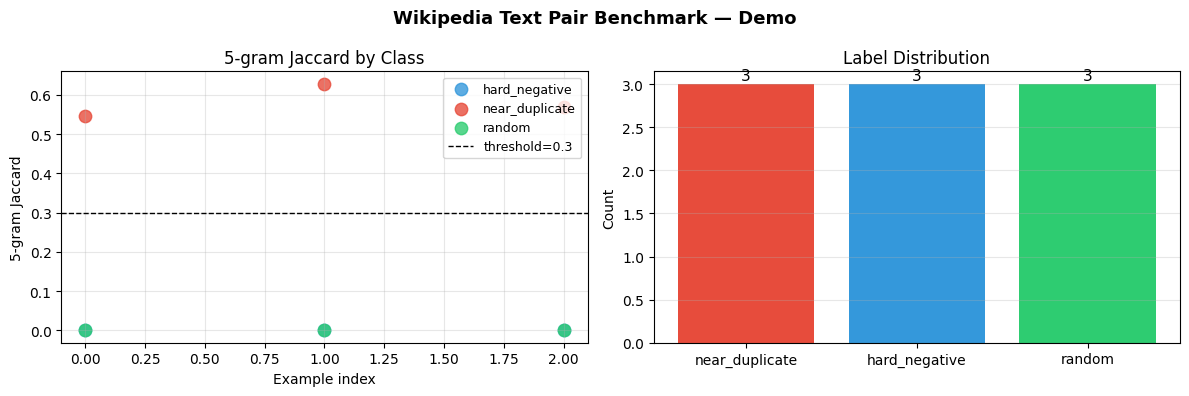


=== Per-Class Jaccard Stats ===
               computed_jaccard_5gram                     word_overlap                    
                                 mean       min       max         mean       min       max
label                                                                                     
hard_negative                0.000000  0.000000  0.000000     0.086604  0.070833  0.111111
near_duplicate               0.581339  0.545279  0.628834     0.637485  0.602174  0.694561
random                       0.000000  0.000000  0.000000     0.081060  0.069900  0.093656


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: 5-gram Jaccard by class
ax = axes[0]
colors = {"near_duplicate": "#e74c3c", "hard_negative": "#3498db", "random": "#2ecc71"}
for lbl, grp in df.groupby("label"):
    ax.scatter(
        range(len(grp)), grp["computed_jaccard_5gram"],
        label=lbl, color=colors.get(lbl, "grey"), alpha=0.8, s=80
    )
ax.axhline(THRESHOLD, color="black", linestyle="--", linewidth=1, label=f"threshold={THRESHOLD}")
ax.set_xlabel("Example index")
ax.set_ylabel(f"{N_GRAM}-gram Jaccard")
ax.set_title(f"{N_GRAM}-gram Jaccard by Class")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Plot 2: Label distribution
ax2 = axes[1]
vc = df["label"].value_counts()
bars = ax2.bar(vc.index, vc.values, color=[colors.get(l, "grey") for l in vc.index])
ax2.set_ylabel("Count")
ax2.set_title("Label Distribution")
for bar, v in zip(bars, vc.values):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.05, str(v), ha="center", fontsize=11)
ax2.grid(alpha=0.3, axis="y")

plt.suptitle("Wikipedia Text Pair Benchmark — Demo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("demo_results.png", dpi=100, bbox_inches="tight")
plt.show()

# Summary table
print("\n=== Per-Class Jaccard Stats ===")
print(df.groupby("label")[["computed_jaccard_5gram", "word_overlap"]].agg(["mean", "min", "max"]).to_string())